In [1]:
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", None)

In [3]:
from plot_utils import topk_barplot, cumsum_plot

In [4]:
sample_size = 25

In [5]:
current_dir = os.getcwd()

data_dir = "tech_challenge-data-us_flights_ml"

In [6]:
flights_csv = "flights.csv"
df_flights = pd.read_csv(os.path.join(current_dir, data_dir, flights_csv))

/tmp/ipykernel_37557/221509293.py:2: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  df_flights = pd.read_csv(os.path.join(current_dir, data_dir, flights_csv))


In [7]:
df_flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              str    
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          str    
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24  CANCELLED

In [8]:
not_cancelled_mask = df_flights["CANCELLED"] == 0

df_flights.loc[not_cancelled_mask, "FLIGHT_SEQUENCE"] = (
    df_flights.loc[not_cancelled_mask, ["TAIL_NUMBER", "YEAR", "MONTH", "DAY", "SCHEDULED_DEPARTURE"]]
    .sort_values(by=["TAIL_NUMBER", "YEAR", "MONTH", "DAY", "SCHEDULED_DEPARTURE"])
    .groupby(["TAIL_NUMBER", "YEAR", "MONTH", "DAY"])
    .cumcount() + 1
)

df_flights["FLIGHT_SEQUENCE"] = df_flights["FLIGHT_SEQUENCE"].astype("Int64")

In [9]:
df_flights.loc[df_flights["TAIL_NUMBER"] == "N3KUAA", ["YEAR", "MONTH", "DAY", "SCHEDULED_DEPARTURE", "AIRLINE", "FLIGHT_NUMBER", "TAIL_NUMBER", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "FLIGHT_SEQUENCE"]].head(n=sample_size)

,YEAR,MONTH,DAY,SCHEDULED_DEPARTURE,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,FLIGHT_SEQUENCE
1,2015,1,1,10,AA,2336,N3KUAA,LAX,PBI,1
2246,2015,1,1,845,AA,2269,N3KUAA,PBI,LAX,2
44685,2015,1,3,2010,AA,2421,N3KUAA,MIA,MCO,1
46255,2015,1,4,510,AA,1323,N3KUAA,MCO,MIA,1
48394,2015,1,4,742,AA,1556,N3KUAA,MIA,PHL,2
51959,2015,1,4,1115,AA,1556,N3KUAA,PHL,MIA,3
61519,2015,1,4,2105,AA,2322,N3KUAA,MIA,EWR,4
62796,2015,1,5,559,AA,1205,N3KUAA,EWR,MIA,1
68416,2015,1,5,1105,AA,2494,N3KUAA,MIA,SJU,2
73165,2015,1,5,1546,AA,2494,N3KUAA,SJU,MIA,3


In [10]:
df_flights_considered = (
    df_flights[(df_flights["CANCELLED"] == 0) & (df_flights["DIVERTED"] == 0)]
    .drop(columns=["CANCELLED", "CANCELLATION_REASON", "DIVERTED"])
)

In [11]:
del df_flights
gc.collect()

0

In [12]:
df_flights_considered.info()

<class 'pandas.DataFrame'>
Index: 5714008 entries, 0 to 5819078
Data columns (total 29 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              str    
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          str    
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  AIR_SYSTEM_DELAY     float64
 24  SECURITY_DELAY

In [13]:
df_flights_considered.sample(n=sample_size)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,FLIGHT_SEQUENCE
3882572,2015,8,29,6,AA,2145,N952UW,DCA,LGA,1400,1355.0,-5.0,32.0,1427.0,89.0,82.0,45.0,214,1512.0,5.0,1529,1517.0,-12.0,NaN,NaN,NaN,NaN,NaN,4
285845,2015,1,19,1,B6,1243,N318JB,DCA,CHS,1735,1724.0,-11.0,17.0,1741.0,102.0,89.0,69.0,444,1850.0,3.0,1917,1853.0,-24.0,NaN,NaN,NaN,NaN,NaN,5
1312510,2015,3,26,4,WN,1250,N956WN,OAK,LAX,1150,1147.0,-3.0,8.0,1155.0,75.0,69.0,55.0,337,1250.0,6.0,1305,1256.0,-9.0,NaN,NaN,NaN,NaN,NaN,3
5359235,2015,12,2,3,WN,2865,N616SW,DAL,AUS,855,849.0,-6.0,12.0,901.0,55.0,57.0,40.0,189,941.0,5.0,950,946.0,-4.0,NaN,NaN,NaN,NaN,NaN,2
3910527,2015,8,31,1,UA,762,N848UA,IAH,SAT,1132,1133.0,1.0,18.0,1151.0,64.0,57.0,36.0,191,1227.0,3.0,1236,1230.0,-6.0,NaN,NaN,NaN,NaN,NaN,2
2861805,2015,6,29,1,WN,3314,N435WN,PIT,MDW,1055,1050.0,-5.0,7.0,1057.0,85.0,76.0,66.0,402,1103.0,3.0,1120,1106.0,-14.0,NaN,NaN,NaN,NaN,NaN,2
3736774,2015,8,20,4,DL,2046,N3759,ATL,PHX,1355,1407.0,12.0,17.0,1424.0,240.0,236.0,215.0,1587,1459.0,4.0,1455,1503.0,8.0,NaN,NaN,NaN,NaN,NaN,2
3601730,2015,8,12,3,AA,1961,N112US,CLT,FLL,1150,1145.0,-5.0,30.0,1215.0,124.0,124.0,92.0,632,1347.0,2.0,1354,1349.0,-5.0,NaN,NaN,NaN,NaN,NaN,2
4629597,2015,10,16,5,AA,2129,N752US,11278,10721,1030,1025.0,-5.0,12.0,1037.0,88.0,76.0,56.0,399,1133.0,8.0,1158,1141.0,-17.0,NaN,NaN,NaN,NaN,NaN,2
3826592,2015,8,26,3,WN,255,N428WN,LAS,MCI,720,715.0,-5.0,9.0,724.0,165.0,152.0,140.0,1139,1144.0,3.0,1205,1147.0,-18.0,NaN,NaN,NaN,NaN,NaN,2


In [14]:
wd_mapping = {
    1: "MON",
    2: "TUE",
    3: "WED",
    4: "THU",
    5: "FRI",
    6: "SAT",
    7: "SUN",
}

df_flights_considered["DAY_OF_WEEK_ABBR"] = pd.Categorical(
    df_flights_considered["DAY_OF_WEEK"],
    categories=wd_mapping.keys(),
    ordered=True
).rename_categories(wd_mapping)

In [15]:
df_flights_considered["ROUTE"] = df_flights_considered["ORIGIN_AIRPORT"].astype(str) + "-" + df_flights_considered["DESTINATION_AIRPORT"].astype(str)

## Sanity checks

In [16]:
df_flights_considered[["SCHEDULED_DEPARTURE", "SCHEDULED_ARRIVAL", "SCHEDULED_TIME", "DEPARTURE_TIME", "DEPARTURE_DELAY", "ARRIVAL_TIME", "ELAPSED_TIME", "ARRIVAL_DELAY"]].isna().sum()

SCHEDULED_DEPARTURE    0
SCHEDULED_ARRIVAL      0
SCHEDULED_TIME         0
DEPARTURE_TIME         0
DEPARTURE_DELAY        0
ARRIVAL_TIME           0
ELAPSED_TIME           0
ARRIVAL_DELAY          0
dtype: int64

In [17]:
df_flights_considered["HOUR"] = df_flights_considered["SCHEDULED_DEPARTURE"] // 100
df_flights_considered["MINUTE"] = df_flights_considered["SCHEDULED_DEPARTURE"] % 100
df_flights_considered["DT_SCHEDULED_DEPARTURE"] = pd.to_datetime(df_flights_considered[["YEAR", "MONTH", "DAY", "HOUR", "MINUTE"]])

df_flights_considered["TD_SCHEDULED_TIME"] = pd.to_timedelta(df_flights_considered["SCHEDULED_TIME"], unit="min")
df_flights_considered["TD_DEPARTURE_DELAY"] = pd.to_timedelta(df_flights_considered["DEPARTURE_DELAY"], unit="min")
df_flights_considered["TD_ELAPSED_TIME"] = pd.to_timedelta(df_flights_considered["ELAPSED_TIME"], unit="min")

df_flights_considered["DT_SCHEDULED_ARRIVAL_CALC"] = df_flights_considered["DT_SCHEDULED_DEPARTURE"] + df_flights_considered["TD_SCHEDULED_TIME"]
df_flights_considered["DT_ARRIVAL_CALC"] = df_flights_considered["DT_SCHEDULED_DEPARTURE"] + df_flights_considered["TD_DEPARTURE_DELAY"] + df_flights_considered["TD_ELAPSED_TIME"]

df_flights_considered["INT_ARRIVAL_DELAY_CALC_1"] = (df_flights_considered["DT_ARRIVAL_CALC"] - df_flights_considered["DT_SCHEDULED_ARRIVAL_CALC"]).dt.total_seconds() / 60
df_flights_considered["INT_ARRIVAL_DELAY_CALC_2"] = (df_flights_considered["TD_DEPARTURE_DELAY"] + df_flights_considered["TD_ELAPSED_TIME"] - df_flights_considered["TD_SCHEDULED_TIME"]).dt.total_seconds() / 60

In [18]:
df_flights_considered[["DT_SCHEDULED_DEPARTURE", "TD_SCHEDULED_TIME", "DT_SCHEDULED_ARRIVAL_CALC", "SCHEDULED_ARRIVAL"]].sample(n=sample_size)

,DT_SCHEDULED_DEPARTURE,TD_SCHEDULED_TIME,DT_SCHEDULED_ARRIVAL_CALC,SCHEDULED_ARRIVAL
396110,2015-01-27 06:25:00,0 days 02:14:00,2015-01-27 08:39:00,839
5063326,2015-11-12 22:45:00,0 days 01:17:00,2015-11-13 00:02:00,2
1446087,2015-04-03 13:50:00,0 days 01:17:00,2015-04-03 15:07:00,1507
3529440,2015-08-08 05:50:00,0 days 01:35:00,2015-08-08 07:25:00,725
2799060,2015-06-25 14:15:00,0 days 04:08:00,2015-06-25 18:23:00,2023
2721374,2015-06-21 06:00:00,0 days 01:44:00,2015-06-21 07:44:00,744
4468555,2015-10-06 09:55:00,0 days 05:25:00,2015-10-06 15:20:00,1220
1650221,2015-04-16 09:10:00,0 days 01:50:00,2015-04-16 11:00:00,1000
5362572,2015-12-02 12:20:00,0 days 00:55:00,2015-12-02 13:15:00,1315
638959,2015-02-12 08:40:00,0 days 04:04:00,2015-02-12 12:44:00,1344


In [19]:
(df_flights_considered["DT_SCHEDULED_ARRIVAL_CALC"].dt.minute != (df_flights_considered["SCHEDULED_ARRIVAL"] % 100)).sum()

np.int64(1)

In [20]:
df_flights_considered.loc[
    df_flights_considered["DT_SCHEDULED_ARRIVAL_CALC"].dt.minute != (df_flights_considered["SCHEDULED_ARRIVAL"] % 100),
    ["AIRLINE", "FLIGHT_NUMBER", "TAIL_NUMBER", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "DT_SCHEDULED_DEPARTURE", "TD_SCHEDULED_TIME", "DT_SCHEDULED_ARRIVAL_CALC", "SCHEDULED_ARRIVAL"]
]

,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DT_SCHEDULED_DEPARTURE,TD_SCHEDULED_TIME,DT_SCHEDULED_ARRIVAL_CALC,SCHEDULED_ARRIVAL
1971228,F9,735,N920FR,ATL,CVG,2015-05-06 08:10:00,0 days 02:55:00,2015-05-06 11:05:00,1110


In [21]:
(df_flights_considered["DT_SCHEDULED_ARRIVAL_CALC"].dt.hour - (df_flights_considered["SCHEDULED_ARRIVAL"] // 100)).value_counts()

 0     2934344
-1      864144
 1      862340
-2      278759
 2      264616
-3      201543
 3      165666
-21      44641
-22      27285
-23      20751
 23      19524
 22      12718
 21       8584
-4        1952
 5        1833
-5        1832
 4        1825
 6         814
-6         811
-20         16
-19          9
-24          1
Name: count, dtype: int64

In [22]:
df_flights_considered[["DT_SCHEDULED_DEPARTURE", "TD_DEPARTURE_DELAY", "DEPARTURE_TIME", "TD_ELAPSED_TIME", "DT_ARRIVAL_CALC", "ARRIVAL_TIME"]].sample(n=sample_size)

,DT_SCHEDULED_DEPARTURE,TD_DEPARTURE_DELAY,DEPARTURE_TIME,TD_ELAPSED_TIME,DT_ARRIVAL_CALC,ARRIVAL_TIME
1955568,2015-05-05 08:59:00,0 days 00:53:00,952.0,0 days 02:34:00,2015-05-05 12:26:00,1126.0
5627991,2015-12-19 14:13:00,-1 days +23:55:00,1408.0,0 days 02:50:00,2015-12-19 16:58:00,1658.0
4613607,2015-10-15 11:15:00,0 days 00:26:00,1141.0,0 days 03:38:00,2015-10-15 15:19:00,1319.0
278015,2015-01-19 09:50:00,-1 days +23:55:00,945.0,0 days 01:25:00,2015-01-19 11:10:00,1110.0
4767412,2015-10-25 08:55:00,-1 days +23:53:00,848.0,0 days 02:18:00,2015-10-25 11:06:00,1006.0
1117219,2015-03-14 12:29:00,0 days 00:06:00,1235.0,0 days 01:18:00,2015-03-14 13:53:00,1353.0
4911825,2015-11-03 13:07:00,-1 days +23:55:00,1302.0,0 days 01:14:00,2015-11-03 14:16:00,1416.0
3524829,2015-08-07 17:52:00,0 days 01:05:00,1857.0,0 days 02:05:00,2015-08-07 21:02:00,2102.0
4997890,2015-11-08 22:40:00,0 days 00:08:00,2248.0,0 days 01:30:00,2015-11-09 00:18:00,18.0
4806887,2015-10-27 16:05:00,0 days 00:04:00,1609.0,0 days 02:00:00,2015-10-27 18:09:00,1709.0


In [23]:
(df_flights_considered["DT_ARRIVAL_CALC"].dt.minute != (df_flights_considered["ARRIVAL_TIME"] % 100)).sum()

np.int64(2)

In [24]:
df_flights_considered.loc[
    df_flights_considered["DT_ARRIVAL_CALC"].dt.minute != (df_flights_considered["ARRIVAL_TIME"] % 100),
    ["AIRLINE", "FLIGHT_NUMBER", "TAIL_NUMBER", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "DT_SCHEDULED_DEPARTURE", "TD_DEPARTURE_DELAY", "DEPARTURE_TIME", "TD_ELAPSED_TIME", "DT_ARRIVAL_CALC", "ARRIVAL_TIME"]
]

,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DT_SCHEDULED_DEPARTURE,TD_DEPARTURE_DELAY,DEPARTURE_TIME,TD_ELAPSED_TIME,DT_ARRIVAL_CALC,ARRIVAL_TIME
1971228,F9,735,N920FR,ATL,CVG,2015-05-06 08:10:00,-1 days +23:54:00,804.0,0 days 03:07:00,2015-05-06 11:11:00,1116.0
2950034,F9,1360,N924FR,PHX,IAH,2015-07-04 19:30:00,-1 days +23:49:00,1919.0,0 days 02:29:00,2015-07-04 21:48:00,2350.0


In [25]:
(df_flights_considered["DT_ARRIVAL_CALC"].dt.hour - (df_flights_considered["ARRIVAL_TIME"] // 100)).value_counts()

 0.0     2933188
 1.0      860690
-1.0      860203
-2.0      276419
 2.0      264468
-3.0      199859
 3.0      167372
-21.0      42935
-22.0      27433
 23.0      23465
-23.0      22401
 22.0      15058
 21.0      10268
-4.0        1949
 5.0        1804
 4.0        1797
-5.0        1603
-24.0       1157
 6.0         805
-6.0         798
 19.0        229
-20.0         44
-19.0         38
 18.0         13
-18.0          9
 20.0          3
Name: count, dtype: int64

In [26]:
df_flights_considered[["ARRIVAL_TIME", "SCHEDULED_ARRIVAL", "ARRIVAL_DELAY", "INT_ARRIVAL_DELAY_CALC_1", "INT_ARRIVAL_DELAY_CALC_2"]].sample(n=sample_size)

,ARRIVAL_TIME,SCHEDULED_ARRIVAL,ARRIVAL_DELAY,INT_ARRIVAL_DELAY_CALC_1,INT_ARRIVAL_DELAY_CALC_2
1723067,2336.0,2346,-10.0,-10.0,-10.0
2749899,1822.0,1830,-8.0,-8.0,-8.0
2172688,1841.0,1825,16.0,16.0,16.0
5215361,2029.0,1946,43.0,43.0,43.0
99275,1121.0,1152,-31.0,-31.0,-31.0
4036458,1538.0,1540,-2.0,-2.0,-2.0
4635103,1733.0,1750,-17.0,-17.0,-17.0
4676223,1447.0,1440,7.0,7.0,7.0
2517790,2257.0,2309,-12.0,-12.0,-12.0
2582783,1807.0,1827,-20.0,-20.0,-20.0


In [27]:
delay_cols = ["ARRIVAL_DELAY", "INT_ARRIVAL_DELAY_CALC_1", "INT_ARRIVAL_DELAY_CALC_2"]
df_flights_considered[delay_cols] = df_flights_considered[delay_cols].astype(int)

In [28]:
(df_flights_considered["INT_ARRIVAL_DELAY_CALC_1"] != df_flights_considered["ARRIVAL_DELAY"]).sum()

np.int64(1)

In [29]:
df_flights_considered.loc[
    df_flights_considered["INT_ARRIVAL_DELAY_CALC_1"] != df_flights_considered["ARRIVAL_DELAY"],
    ["AIRLINE", "FLIGHT_NUMBER", "TAIL_NUMBER", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "DT_ARRIVAL_CALC", "ARRIVAL_TIME", "SCHEDULED_ARRIVAL", "ARRIVAL_DELAY", "INT_ARRIVAL_DELAY_CALC_1"]
]

,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DT_ARRIVAL_CALC,ARRIVAL_TIME,SCHEDULED_ARRIVAL,ARRIVAL_DELAY,INT_ARRIVAL_DELAY_CALC_1
2950034,F9,1360,N924FR,PHX,IAH,2015-07-04 21:48:00,2350.0,10,-20,-22


In [30]:
(df_flights_considered["INT_ARRIVAL_DELAY_CALC_2"] != df_flights_considered["ARRIVAL_DELAY"]).sum()

np.int64(1)

In [31]:
df_flights_considered.loc[
    df_flights_considered["INT_ARRIVAL_DELAY_CALC_2"] != df_flights_considered["ARRIVAL_DELAY"],
    ["AIRLINE", "FLIGHT_NUMBER", "TAIL_NUMBER", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "DT_ARRIVAL_CALC", "ARRIVAL_TIME", "SCHEDULED_ARRIVAL", "ARRIVAL_DELAY", "INT_ARRIVAL_DELAY_CALC_2"]
]

,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DT_ARRIVAL_CALC,ARRIVAL_TIME,SCHEDULED_ARRIVAL,ARRIVAL_DELAY,INT_ARRIVAL_DELAY_CALC_2
2950034,F9,1360,N924FR,PHX,IAH,2015-07-04 21:48:00,2350.0,10,-20,-22


## Delayed

In [32]:
tol_min = 0
df_flights_considered["DELAYED"] = df_flights_considered["ARRIVAL_DELAY"] > tol_min

In [33]:
df_flights_considered["DELAYED"].value_counts(normalize=True)

DELAYED
False    0.634775
True     0.365225
Name: proportion, dtype: float64

In [34]:
delay_reason_cols = ["AIR_SYSTEM_DELAY", "SECURITY_DELAY", "AIRLINE_DELAY", "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY"]
df_flights_considered.loc[df_flights_considered["DELAYED"], delay_reason_cols].isna().sum()

AIR_SYSTEM_DELAY       1023457
SECURITY_DELAY         1023457
AIRLINE_DELAY          1023457
LATE_AIRCRAFT_DELAY    1023457
WEATHER_DELAY          1023457
dtype: int64

In [35]:
df_flights_considered.loc[df_flights_considered["DELAYED"], ["ARRIVAL_DELAY"] + delay_reason_cols].sample(n=sample_size)

,ARRIVAL_DELAY,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
61057,34,10.0,0.0,0.0,24.0,0.0
653296,10,NaN,NaN,NaN,NaN,NaN
696920,58,0.0,0.0,58.0,0.0,0.0
4915230,4,NaN,NaN,NaN,NaN,NaN
3234742,29,0.0,0.0,0.0,29.0,0.0
820099,10,NaN,NaN,NaN,NaN,NaN
1791750,13,NaN,NaN,NaN,NaN,NaN
3290866,21,0.0,0.0,1.0,20.0,0.0
335455,2,NaN,NaN,NaN,NaN,NaN
574072,12,NaN,NaN,NaN,NaN,NaN


In [36]:
df_flights_considered.loc[df_flights_considered["DELAYED"], delay_reason_cols].sum(axis=1, skipna=False).value_counts().sort_index()

15.0      39941
16.0      37719
17.0      35139
18.0      33340
19.0      31209
          ...  
1636.0        2
1638.0        1
1665.0        1
1898.0        1
1971.0        1
Name: count, Length: 1142, dtype: int64

In [37]:
tol_min = 15
df_flights_considered["DELAYED"] = df_flights_considered["ARRIVAL_DELAY"] >= tol_min

In [38]:
df_flights_considered["DELAYED"].value_counts(normalize=True)

DELAYED
False    0.813889
True     0.186111
Name: proportion, dtype: float64

In [39]:
df_flights_considered.loc[df_flights_considered["DELAYED"], delay_reason_cols].isna().sum()

AIR_SYSTEM_DELAY       0
SECURITY_DELAY         0
AIRLINE_DELAY          0
LATE_AIRCRAFT_DELAY    0
WEATHER_DELAY          0
dtype: int64

In [40]:
df_flights_considered.loc[~df_flights_considered["DELAYED"], delay_reason_cols].isna().sum()

AIR_SYSTEM_DELAY       4650569
SECURITY_DELAY         4650569
AIRLINE_DELAY          4650569
LATE_AIRCRAFT_DELAY    4650569
WEATHER_DELAY          4650569
dtype: int64

In [41]:
df_flights_considered[~df_flights_considered["DELAYED"]].shape[0]

4650569

In [42]:
(df_flights_considered.loc[df_flights_considered["DELAYED"], delay_reason_cols].sum(axis=1).astype(int) != df_flights_considered.loc[df_flights_considered["DELAYED"], "ARRIVAL_DELAY"]).sum()

np.int64(0)

<Axes: >

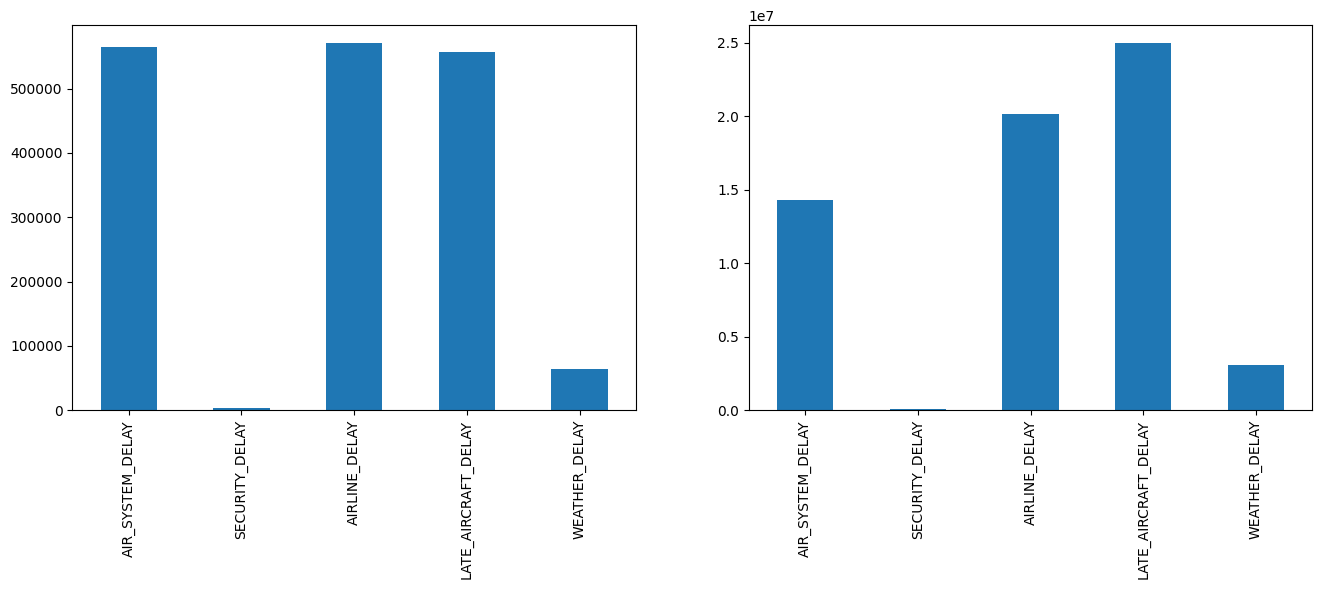

In [43]:
fig, (axc, axs) = plt.subplots(1, 2, figsize=(16, 5))

df_flights_considered.loc[df_flights_considered["DELAYED"], delay_reason_cols].gt(0).sum().plot(kind="bar", ax=axc)
df_flights_considered.loc[df_flights_considered["DELAYED"], delay_reason_cols].sum().plot(kind="bar", ax=axs)

In [44]:
plot_opts = dict(
    kind="bar",
    stacked=True,
    color=["deepskyblue", "gainsboro"],
    figsize=(8, 5),
)

<Axes: xlabel='MONTH'>

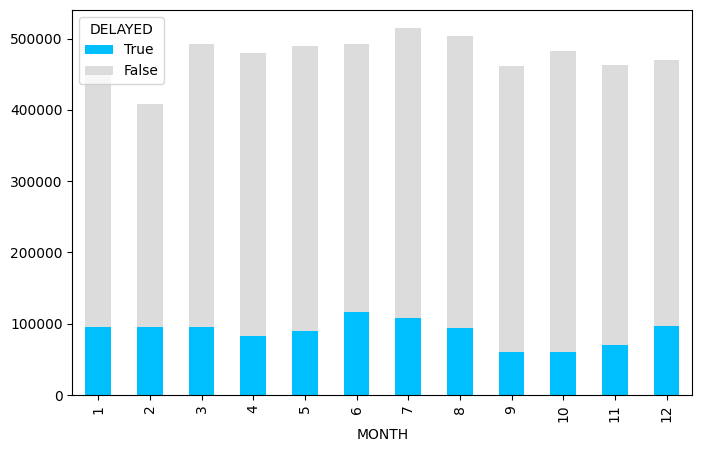

In [45]:
cols = ["MONTH", "DELAYED"]

df_flights_considered[cols].value_counts().unstack().iloc[:, [1, 0]].plot(**plot_opts)

<Axes: xlabel='DAY'>

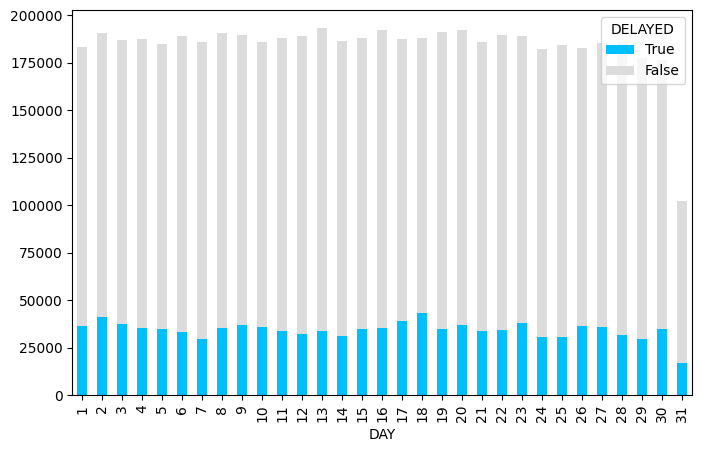

In [46]:
cols = ["DAY", "DELAYED"]

df_flights_considered[cols].value_counts().sort_index().unstack().iloc[:, [1, 0]].plot(**plot_opts)

<Axes: xlabel='DAY_OF_WEEK_ABBR'>

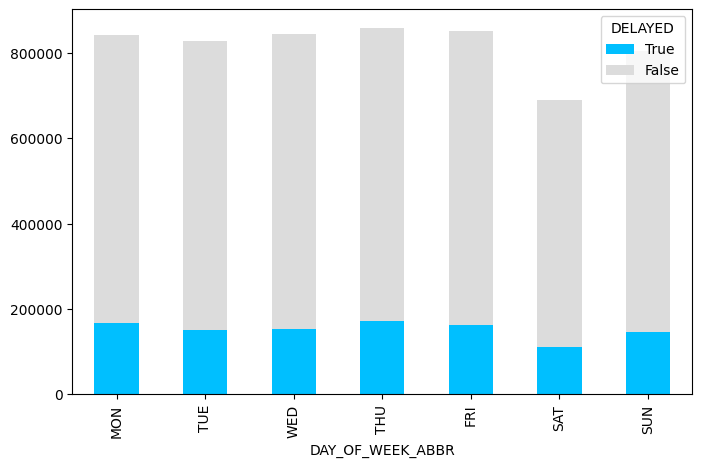

In [47]:
cols = ["DAY_OF_WEEK_ABBR", "DELAYED"]

df_flights_considered[cols].value_counts().sort_index().unstack().iloc[:, [1, 0]].plot(**plot_opts)

<Axes: xlabel='HOUR'>

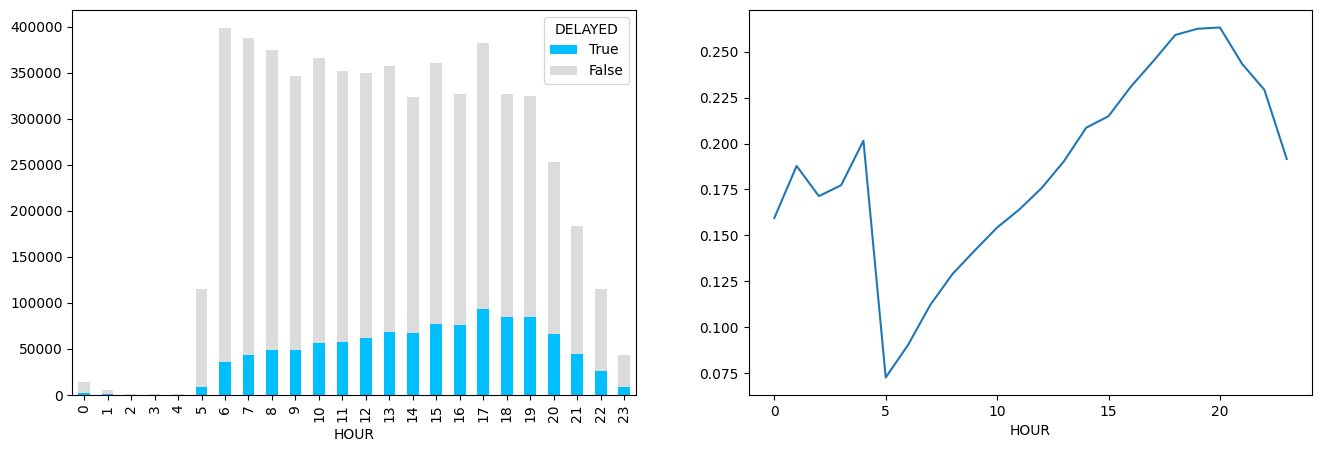

In [48]:
fig, (axb, axl) = plt.subplots(1, 2, figsize=(16, 5))
plot_opts_custom = {k: v for k, v in plot_opts.items() if k != "figsize"}

cols = ["HOUR", "DELAYED"]

df_flights_considered[cols].value_counts().sort_index().unstack().iloc[:, [1, 0]].plot(**plot_opts_custom, ax=axb)
(df_flights_considered.loc[df_flights_considered["DELAYED"], "HOUR"].value_counts() / df_flights_considered["HOUR"].value_counts()).sort_index().plot(kind="line", ax=axl)

<Axes: xlabel='ORIGIN_AIRPORT'>

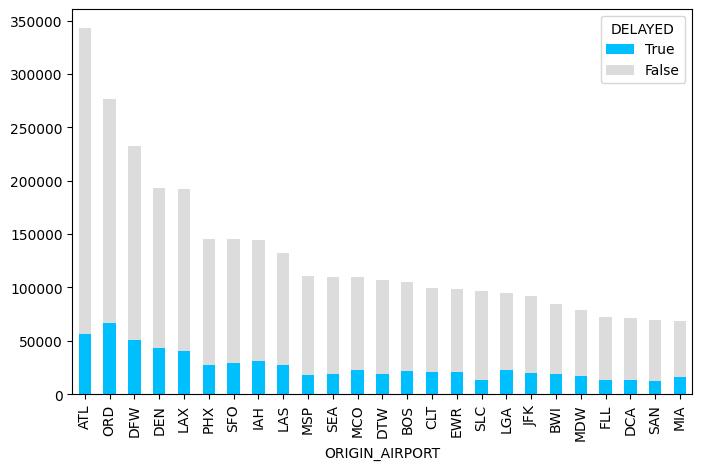

In [49]:
cols = ["ORIGIN_AIRPORT", "DELAYED"]

df_flights_considered[cols].value_counts().unstack(fill_value=0).assign(sum_temp=lambda df: df[False] + df[True]).sort_values(by="sum_temp", ascending=False).head(25).iloc[:, [1, 0]].plot(**plot_opts)

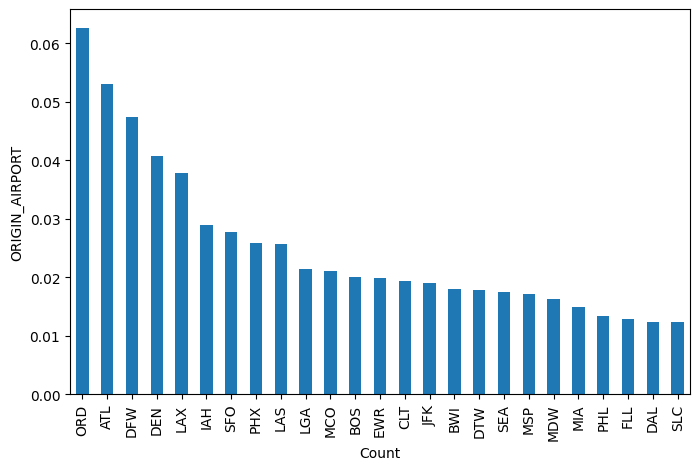

In [50]:
_ = topk_barplot(df_flights_considered.loc[df_flights_considered["DELAYED"], "ORIGIN_AIRPORT"], normalize=True, k=25, group_others=False)
plt.show()

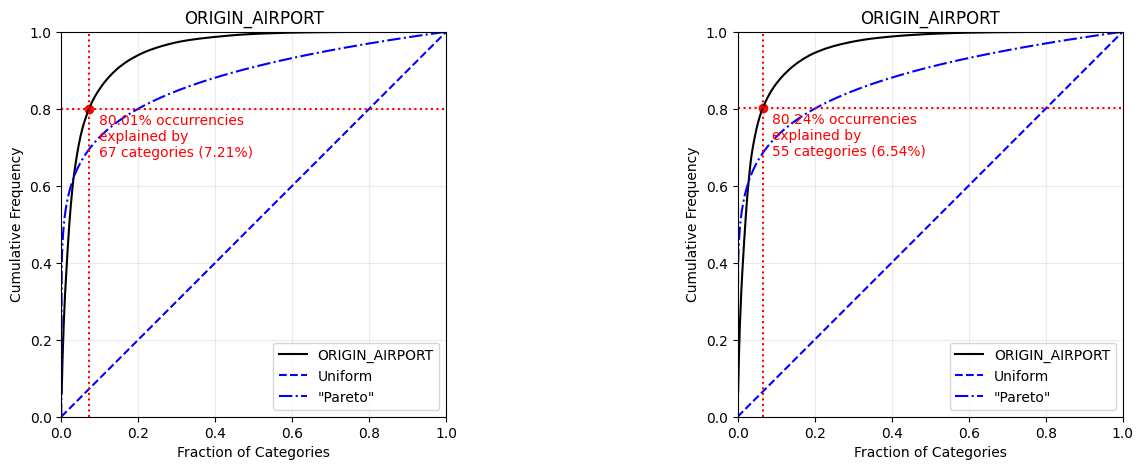

In [51]:
fig, (axc, axd) = plt.subplots(1, 2, figsize=(16, 5))

_ = cumsum_plot(df_flights_considered["ORIGIN_AIRPORT"], annotate=True, threshold=0.8, ax=axc)
_ = cumsum_plot(df_flights_considered.loc[df_flights_considered["DELAYED"], "ORIGIN_AIRPORT"], annotate=True, threshold=0.8, ax=axd)

<Axes: xlabel='DESTINATION_AIRPORT'>

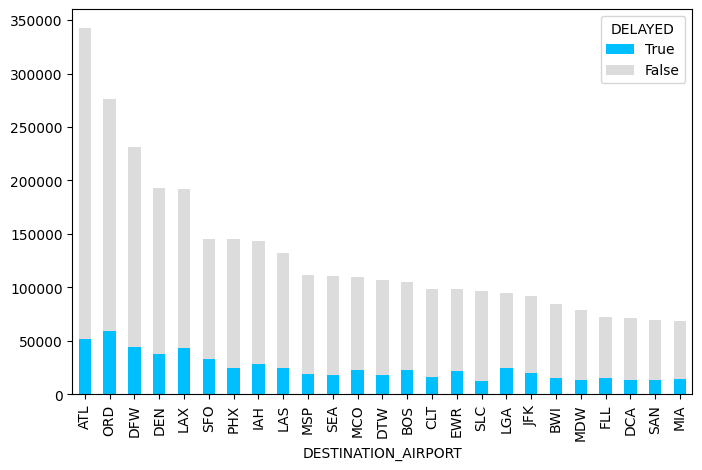

In [52]:
cols = ["DESTINATION_AIRPORT", "DELAYED"]

df_flights_considered[cols].value_counts().unstack(fill_value=0).assign(sum_temp=lambda df: df[False] + df[True]).sort_values(by="sum_temp", ascending=False).head(25).iloc[:, [1, 0]].plot(**plot_opts)

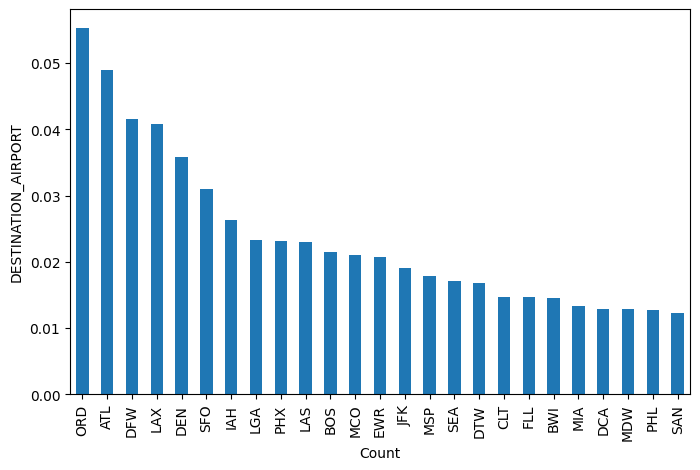

In [53]:
_ = topk_barplot(df_flights_considered.loc[df_flights_considered["DELAYED"], "DESTINATION_AIRPORT"], normalize=True, k=25, group_others=False)
plt.show()

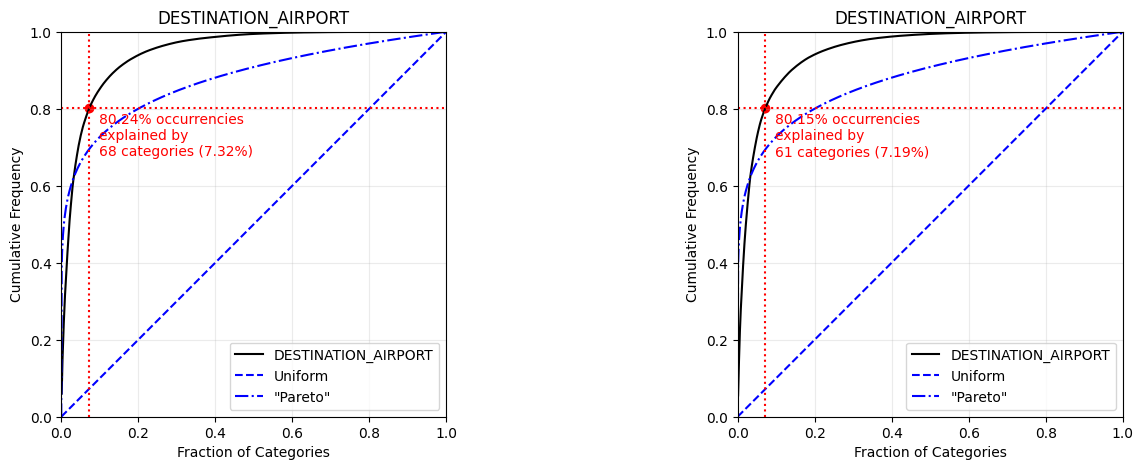

In [54]:
fig, (axc, axd) = plt.subplots(1, 2, figsize=(16, 5))

_ = cumsum_plot(df_flights_considered["DESTINATION_AIRPORT"], annotate=True, threshold=0.8, ax=axc)
_ = cumsum_plot(df_flights_considered.loc[df_flights_considered["DELAYED"], "DESTINATION_AIRPORT"], annotate=True, threshold=0.8, ax=axd)

<Axes: xlabel='ROUTE'>

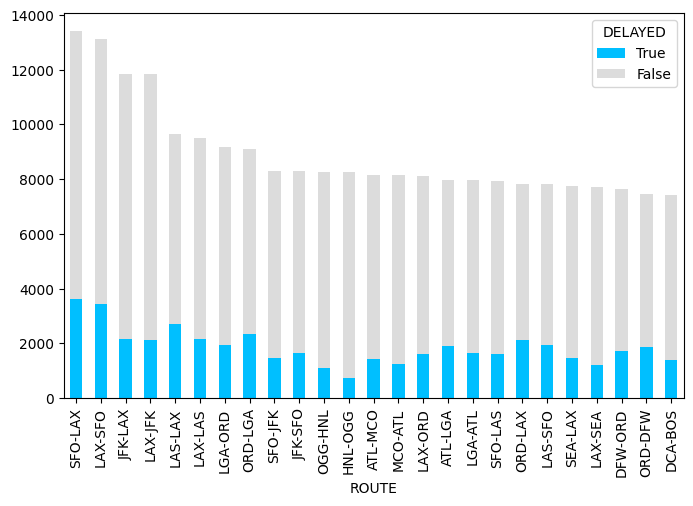

In [55]:
cols = ["ROUTE", "DELAYED"]

df_flights_considered[cols].value_counts().unstack(fill_value=0).assign(sum_temp=lambda df: df[False] + df[True]).sort_values(by="sum_temp", ascending=False).head(25).iloc[:, [1, 0]].plot(**plot_opts)

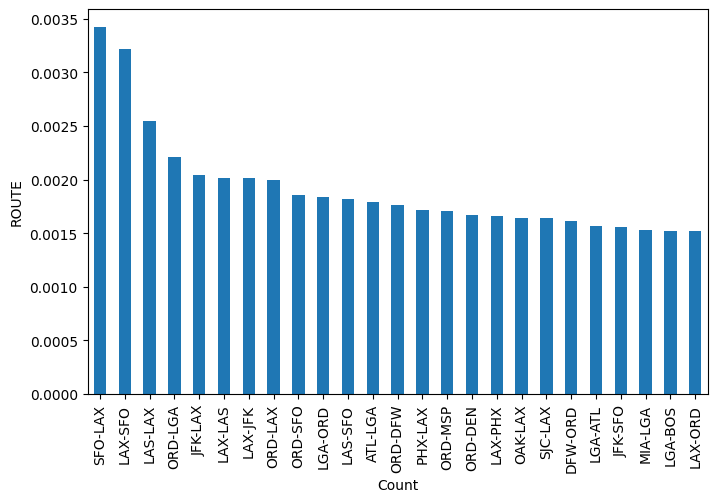

In [56]:
_ = topk_barplot(df_flights_considered.loc[df_flights_considered["DELAYED"], "ROUTE"], normalize=True, k=25, group_others=False)
plt.show()

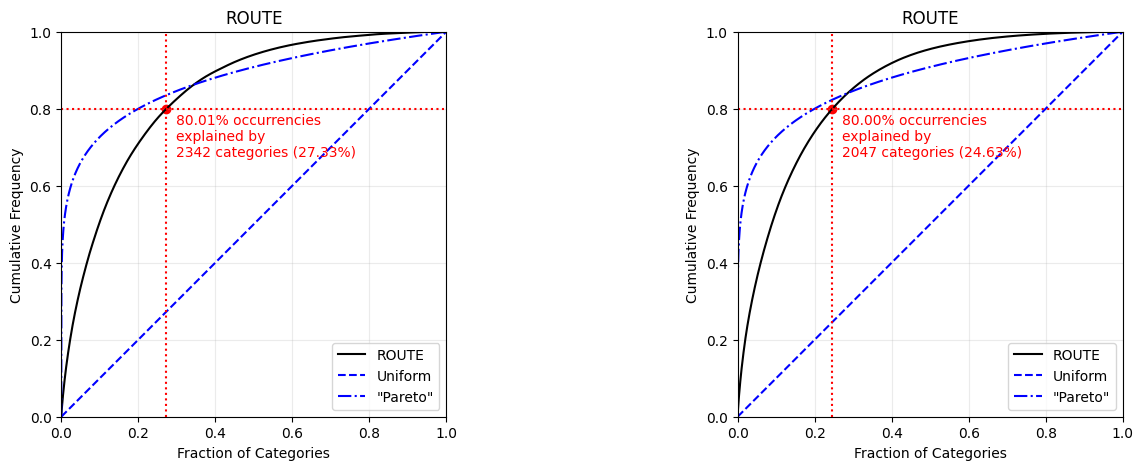

In [57]:
fig, (axc, axd) = plt.subplots(1, 2, figsize=(16, 5))

_ = cumsum_plot(df_flights_considered["ROUTE"], annotate=True, threshold=0.8, ax=axc)
_ = cumsum_plot(df_flights_considered.loc[df_flights_considered["DELAYED"], "ROUTE"], annotate=True, threshold=0.8, ax=axd)

<Axes: xlabel='AIRLINE'>

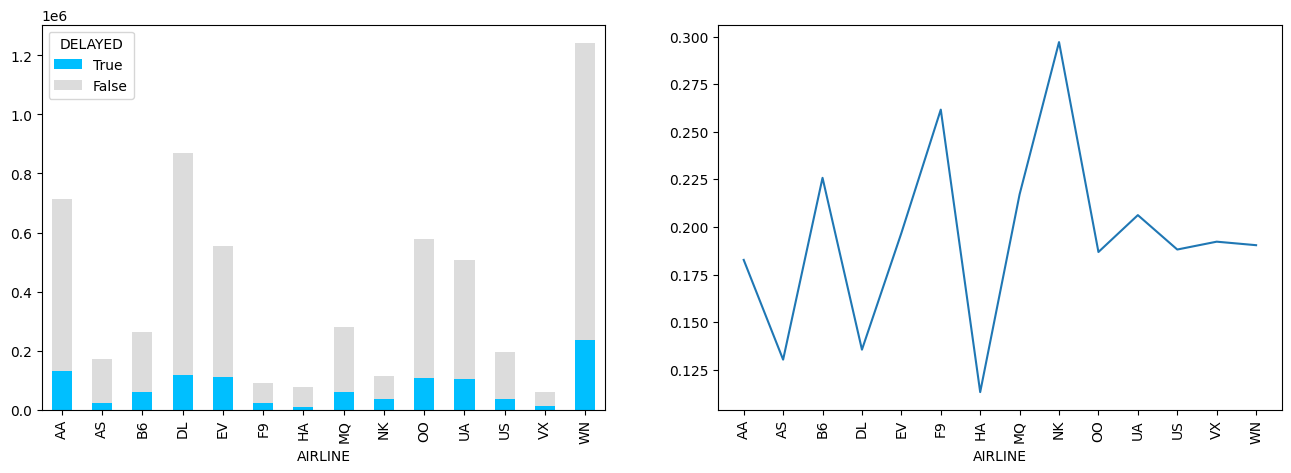

In [58]:
fig, (axb, axl) = plt.subplots(1, 2, figsize=(16, 5))
plot_opts_custom = {k: v for k, v in plot_opts.items() if k != "figsize"}

cols = ["AIRLINE", "DELAYED"]

df_flights_considered[cols].value_counts().unstack(fill_value=0).sort_index().iloc[:, [1, 0]].plot(**plot_opts_custom, ax=axb)
airline_ratios = (df_flights_considered.loc[df_flights_considered["DELAYED"], "AIRLINE"].value_counts() / df_flights_considered["AIRLINE"].value_counts()).sort_index()
airline_ratios.plot(kind="line", xticks=range(len(airline_ratios)), use_index=True, rot=90, ax=axl)

<Axes: xlabel='FLIGHT_NUMBER'>

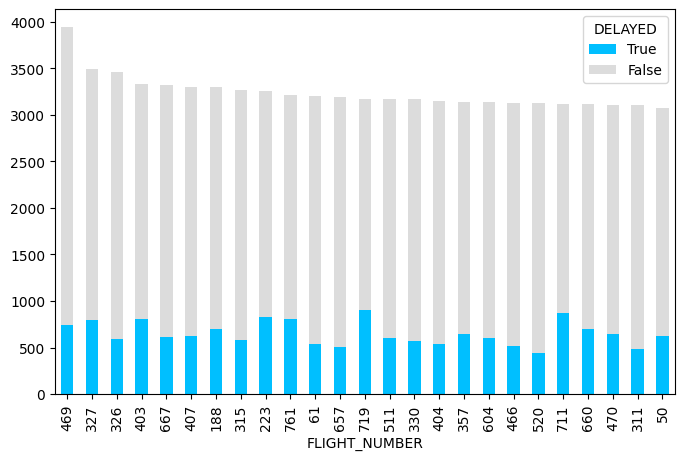

In [59]:
cols = ["FLIGHT_NUMBER", "DELAYED"]

df_flights_considered[cols].value_counts().unstack(fill_value=0).assign(sum_temp=lambda df: df[False] + df[True]).sort_values(by="sum_temp", ascending=False).head(25).iloc[:, [1, 0]].plot(**plot_opts)

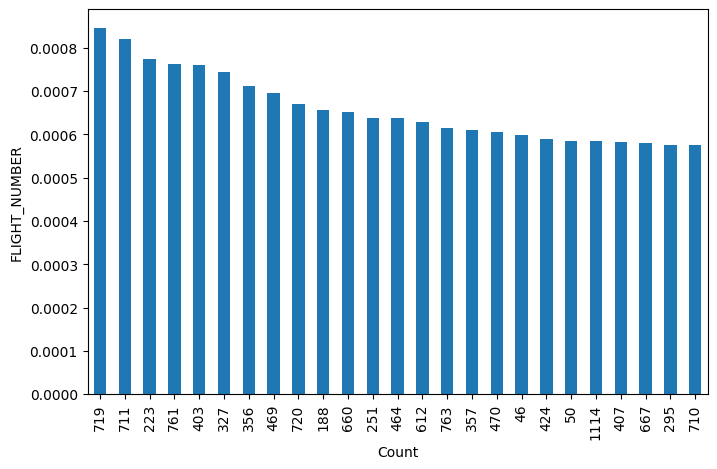

In [60]:
_ = topk_barplot(df_flights_considered.loc[df_flights_considered["DELAYED"], "FLIGHT_NUMBER"], normalize=True, k=25, group_others=False)
plt.show()

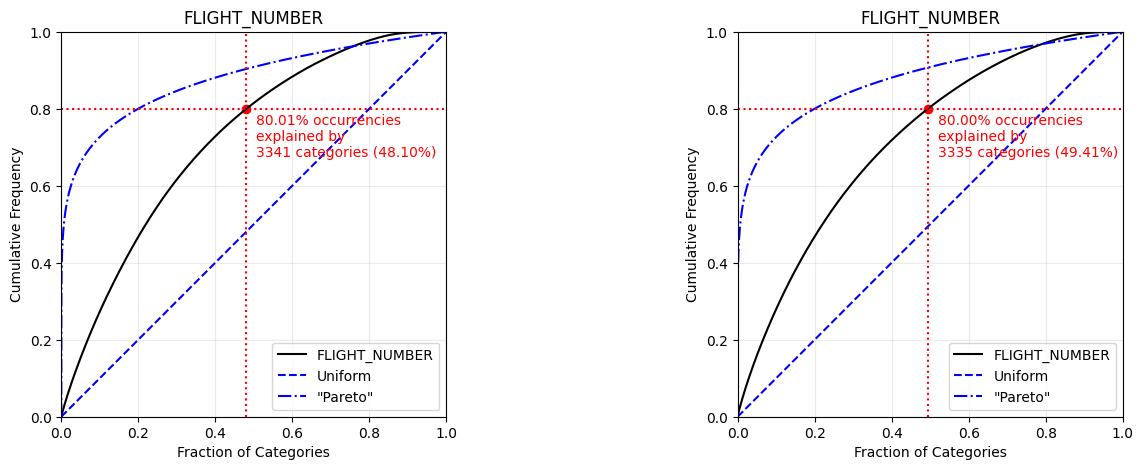

In [61]:
fig, (axc, axd) = plt.subplots(1, 2, figsize=(16, 5))

_ = cumsum_plot(df_flights_considered["FLIGHT_NUMBER"], annotate=True, threshold=0.8, ax=axc)
_ = cumsum_plot(df_flights_considered.loc[df_flights_considered["DELAYED"], "FLIGHT_NUMBER"], annotate=True, threshold=0.8, ax=axd)

<Axes: xlabel='TAIL_NUMBER'>

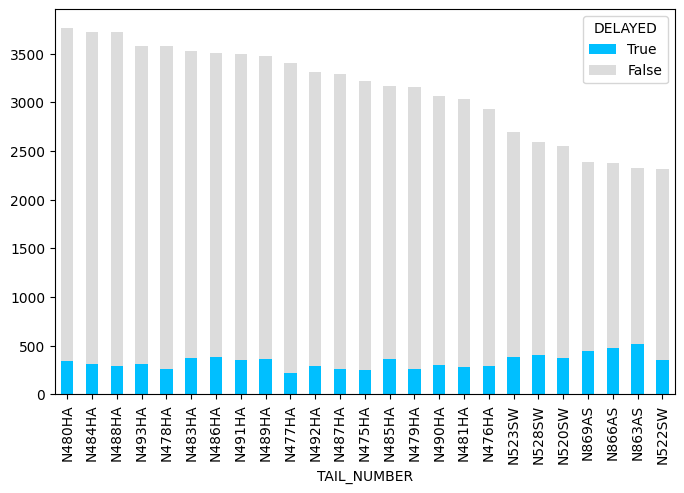

In [62]:
cols = ["TAIL_NUMBER", "DELAYED"]

df_flights_considered[cols].value_counts().unstack(fill_value=0).assign(sum_temp=lambda df: df[False] + df[True]).sort_values(by="sum_temp", ascending=False).head(25).iloc[:, [1, 0]].plot(**plot_opts)

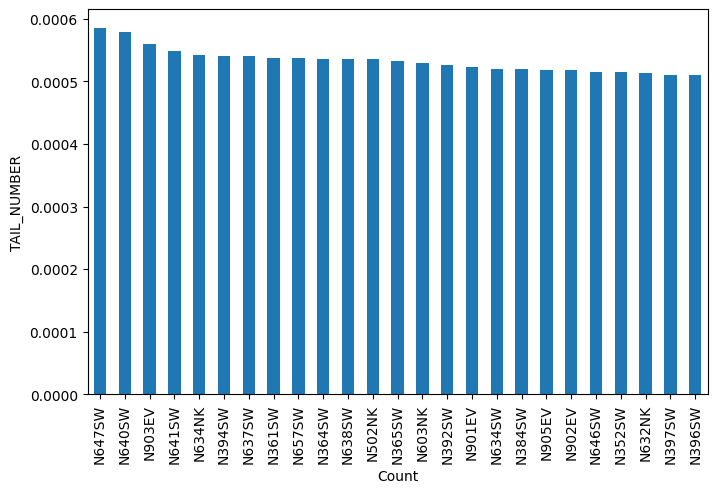

In [63]:
_ = topk_barplot(df_flights_considered.loc[df_flights_considered["DELAYED"], "TAIL_NUMBER"], normalize=True, k=25, group_others=False)
plt.show()

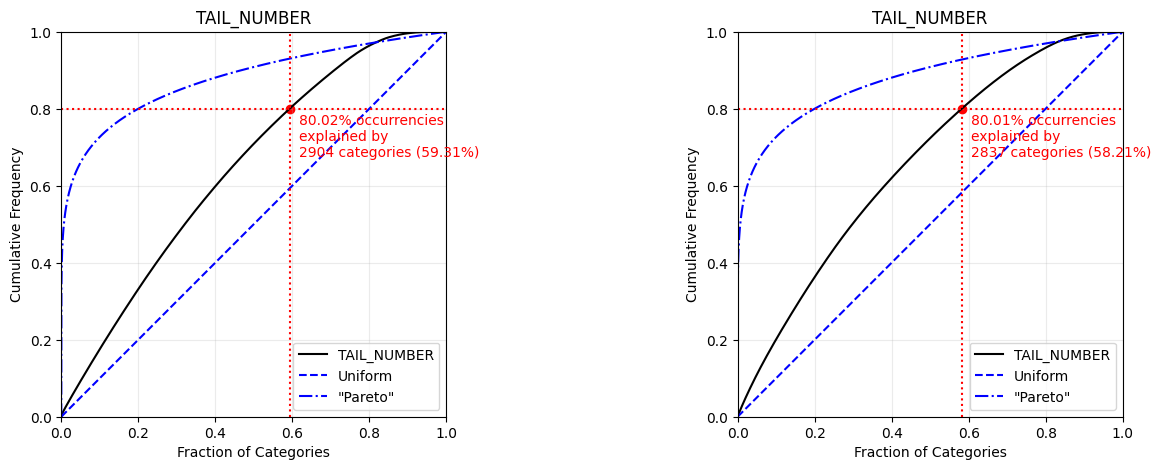

In [64]:
fig, (axc, axd) = plt.subplots(1, 2, figsize=(16, 5))

_ = cumsum_plot(df_flights_considered["TAIL_NUMBER"], annotate=True, threshold=0.8, ax=axc)
_ = cumsum_plot(df_flights_considered.loc[df_flights_considered["DELAYED"], "TAIL_NUMBER"], annotate=True, threshold=0.8, ax=axd)

<Axes: xlabel='FLIGHT_SEQUENCE'>

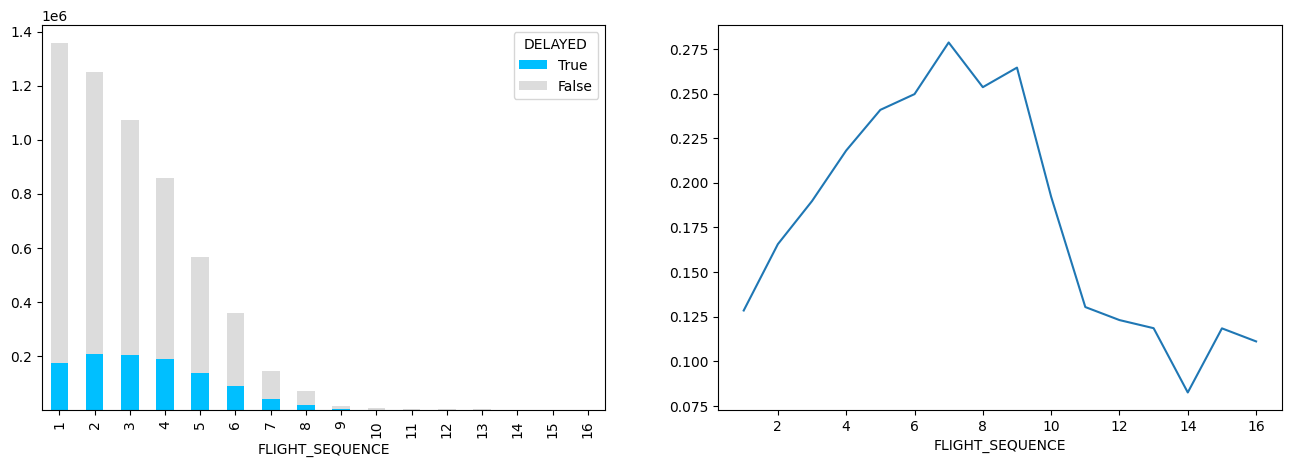

In [65]:
fig, (axb, axl) = plt.subplots(1, 2, figsize=(16, 5))
plot_opts_custom = {k: v for k, v in plot_opts.items() if k != "figsize"}

cols = ["FLIGHT_SEQUENCE", "DELAYED"]

df_flights_considered[cols].value_counts().sort_index().unstack().iloc[:, [1, 0]].plot(**plot_opts_custom, ax=axb)
(df_flights_considered.loc[df_flights_considered["DELAYED"], "FLIGHT_SEQUENCE"].value_counts() / df_flights_considered["FLIGHT_SEQUENCE"].value_counts()).sort_index().plot(kind="line", ax=axl)

<Axes: ylabel='Frequency'>

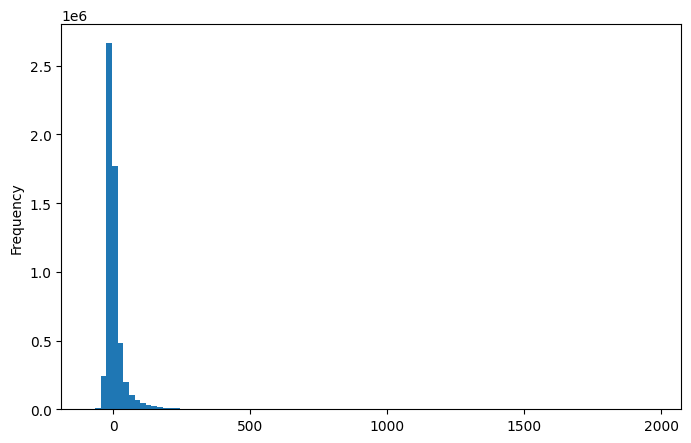

In [66]:
df_flights_considered["ARRIVAL_DELAY"].plot(kind="hist", bins=100, figsize=(8, 5))

In [67]:
df_flights_considered["ARRIVAL_DELAY"].describe()

count    5.714008e+06
mean     4.407057e+00
std      3.927130e+01
min     -8.700000e+01
25%     -1.300000e+01
50%     -5.000000e+00
75%      8.000000e+00
max      1.971000e+03
Name: ARRIVAL_DELAY, dtype: float64

<Axes: xlabel='MONTH', ylabel='ARRIVAL_DELAY'>

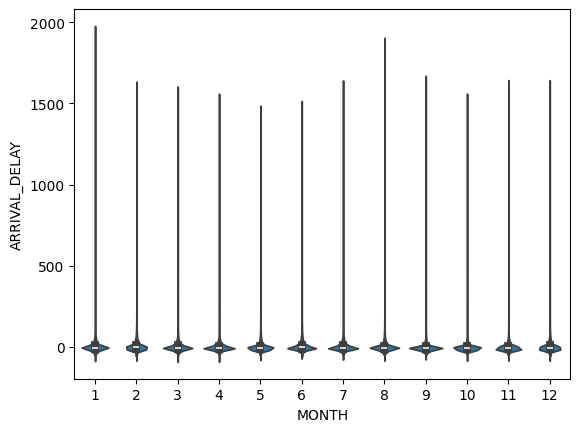

In [68]:
cols = [
    x := "MONTH",
    y := "ARRIVAL_DELAY",
]

sns.violinplot(data=df_flights_considered[cols], x=x, y=y)

<Axes: xlabel='DAY', ylabel='ARRIVAL_DELAY'>

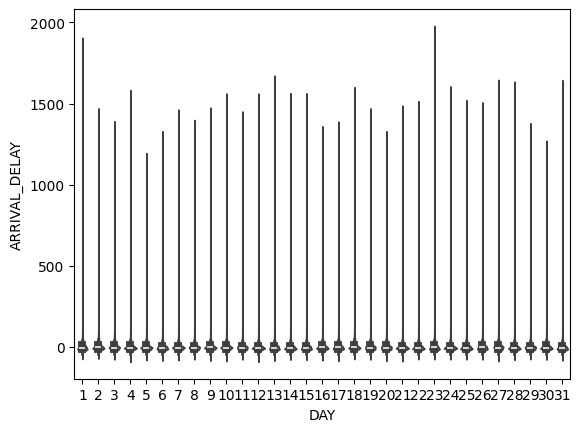

In [69]:
cols = [
    x := "DAY",
    y := "ARRIVAL_DELAY",
]

sns.violinplot(data=df_flights_considered[cols], x=x, y=y)

<Axes: xlabel='DAY_OF_WEEK_ABBR', ylabel='ARRIVAL_DELAY'>

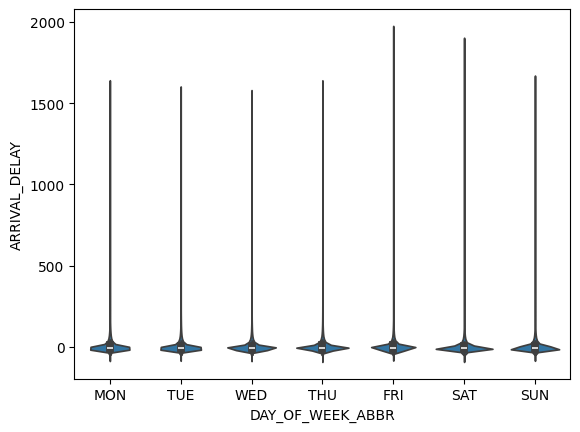

In [70]:
cols = [
    x := "DAY_OF_WEEK_ABBR",
    y := "ARRIVAL_DELAY",
]

sns.violinplot(data=df_flights_considered[cols], x=x, y=y)

<Axes: xlabel='HOUR', ylabel='ARRIVAL_DELAY'>

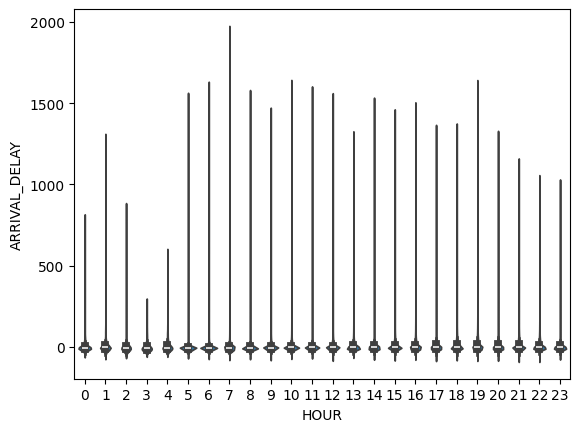

In [71]:
cols = [
    x := "HOUR",
    y := "ARRIVAL_DELAY",
]

sns.violinplot(data=df_flights_considered[cols], x=x, y=y)

<Axes: xlabel='AIRLINE', ylabel='ARRIVAL_DELAY'>

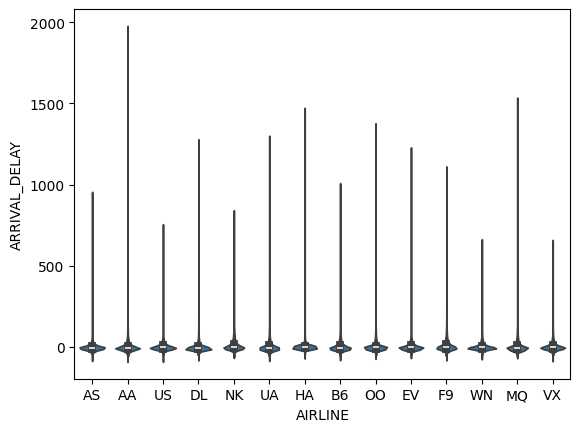

In [72]:
cols = [
    x := "AIRLINE",
    y := "ARRIVAL_DELAY",
]

sns.violinplot(data=df_flights_considered[cols], x=x, y=y)

<Axes: xlabel='FLIGHT_SEQUENCE', ylabel='ARRIVAL_DELAY'>

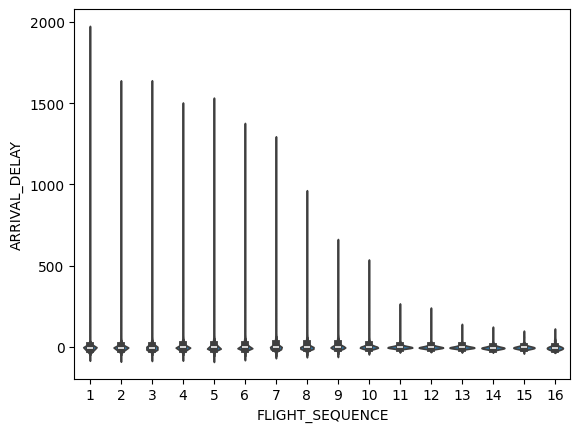

In [73]:
cols = [
    x := "FLIGHT_SEQUENCE",
    y := "ARRIVAL_DELAY",
]

sns.violinplot(data=df_flights_considered[cols], x=x, y=y)

<Axes: xlabel='DISTANCE', ylabel='ARRIVAL_DELAY'>

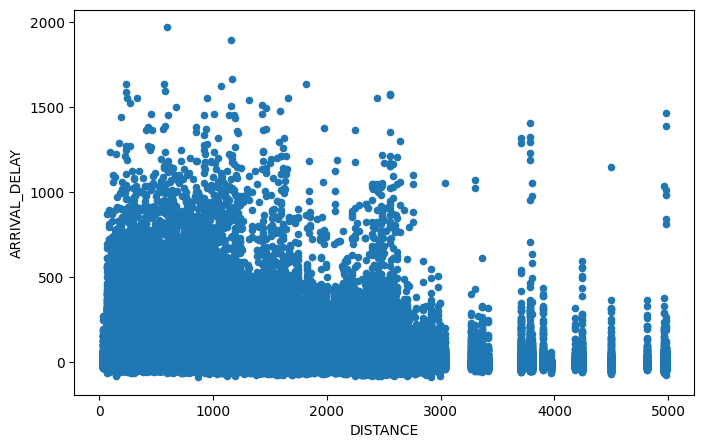

In [74]:
cols = [
    x := "DISTANCE",
    y := "ARRIVAL_DELAY",
]

df_flights_considered[cols].plot(kind="scatter", x=x, y=y, figsize=(8, 5))

<Axes: xlabel='SCHEDULED_TIME', ylabel='ARRIVAL_DELAY'>

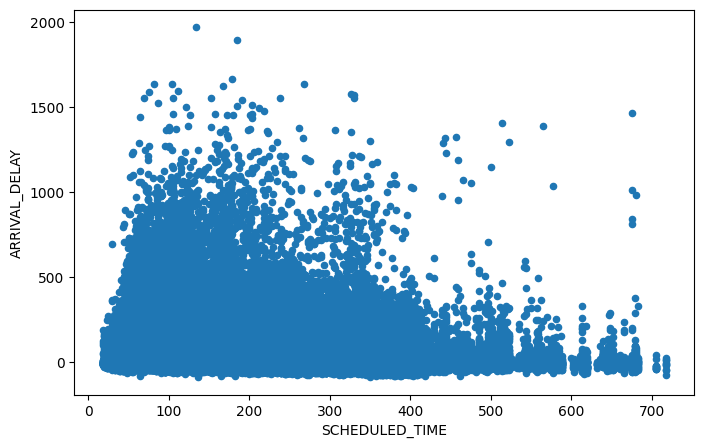

In [75]:
cols = [
    x := "SCHEDULED_TIME",
    y := "ARRIVAL_DELAY",
]

df_flights_considered[cols].plot(kind="scatter", x=x, y=y, figsize=(8, 5))